In [2]:
import os, shutil, pathlib, json
import numpy as np
import jax
from jax import value_and_grad, jit, vmap, grad, random
import jax.numpy as jnp
import flax.linen as nn
import matplotlib.pyplot as plt
from absl import logging
import ml_collections
import optax

from typing import Any, Callable, Sequence, Optional, List, Tuple

import time
import wandb

# from action_angle_networks import train, analysis
# from action_angle_networks.simulation import harmonic_motion_simulation as hsim
# from action_angle_networks.configs.harmonic_motion import default as hm_default

%config InlineBackend.figure_format = 'retina'
logging.set_verbosity(logging.INFO)

In [3]:
# Simulate 1d harmonic oscillator
#key = jax.random.PRNGKey(0)
# Simulate 1d harmonic oscillator

import numpy as np
from dataclasses import dataclass
from typing import Optional, Tuple, Dict

@dataclass
class HarmonicParams:
    n: int
    m: np.ndarray         # (n,) masses per oscillator
    k_wall: float         # wall spring constant
    k_pair: float         # pairwise coupling spring constant
    A_modes: np.ndarray   # (n,) amplitudes per normal mode
    phi_modes: np.ndarray # (n,) phases per normal mode (radians)

def sample_harmonic_params(
    n: int,
    m_range: Tuple[float, float] = (1.0, 5.0),
    k_wall: float = 0.01,
    k_pair: float = 0.005,
    A_range: Tuple[float, float] = (1.0, 3.0),
    seed: Optional[int] = 0,
) -> HarmonicParams:
    rng = np.random.default_rng(seed)
    m = rng.uniform(*m_range, size=(n,)).astype(np.float64)
    # Normal-mode amplitudes/phases
    A_modes = rng.uniform(*A_range, size=(n,)).astype(np.float64)
    phi_modes = rng.uniform(0.0, 2*np.pi, size=(n,)).astype(np.float64)
    return HarmonicParams(
        n=n, m=m, k_wall=float(k_wall), k_pair=float(k_pair),
        A_modes=A_modes, phi_modes=phi_modes
    )

def _normal_mode_eigendecomposition(params: HarmonicParams):
    """
    Returns eigenvalues/eigenvectors for q¨ = M^{-1} L q.
    Repoに合わせて L = -(k_wall + n*k_pair) I + k_pair 1 1^T を用い、
    固有値は負になる（w = sqrt(-eigvals)）。
    """
    n = params.n
    I = np.eye(n)
    J = np.ones((n, n))
    L = -(params.k_wall + n * params.k_pair) * I + params.k_pair * J
    M_inv = np.diag(1.0 / params.m)
    M_inv_L = M_inv @ L
    eigvals, eigvecs = np.linalg.eig(M_inv_L)
    eigvals = eigvals.real
    eigvecs = eigvecs.real
    return eigvals, eigvecs  # (n,), (n,n)

def simulate_coupled_1d_harmonic(
    params: HarmonicParams, num_steps: int, dt: float
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, Dict]:
    """
    Returns:
      t: (T,)
      q: (T, n) positions
      p: (T, n) momenta  (p = m * dq/dt)
      aux: dict with eigvals/eigvecs/w
    """
    n = params.n
    t = np.arange(num_steps, dtype=np.float64) * float(dt)

    # Normal modes
    eigvals, V = _normal_mode_eigendecomposition(params)
    w = np.sqrt(np.clip(-eigvals, a_min=0.0, a_max=None))  # angular freq

    # Mode-space trajectories
    Wt_phi = t[:, None] * w[None, :] + params.phi_modes[None, :]  # (T, n)
    q_mode = params.A_modes[None, :] * np.cos(Wt_phi)              # (T, n)
    qdot_mode = -params.A_modes[None, :] * (w[None, :]) * np.sin(Wt_phi)  # (T, n)

    # Map back to physical coords: q = V q_mode, qdot = V qdot_mode
    q = q_mode @ V.T
    qdot = qdot_mode @ V.T
    p = qdot * params.m[None, :]  # momentum = m * qdot

    aux = {"eigvals": eigvals, "eigvecs": V, "w": w}
    return t, q, p, aux

# # Example: quick sanity check
# if __name__ == "__main__":
#     n = 3
#     params = sample_harmonic_params(n=n, m_range=(1.0, 3.0), k_wall=0.01, k_pair=0.005, A_range=(1.0, 2.0), seed=42)
#     T = 400
#     dt = 0.1
#     t, q, p, aux = simulate_coupled_1d_harmonic(params, num_steps=T, dt=dt)
#     print("q shape:", q.shape, "p shape:", p.shape)



In [4]:
# Example: quick sanity check
n = 3
params = sample_harmonic_params(n=n, m_range=(1.0, 3.0), k_wall=0.01, k_pair=0.005, A_range=(1.0, 2.0), seed=42)
T = 5000
dt = 0.1
t, q, p, aux = simulate_coupled_1d_harmonic(params, num_steps=T, dt=dt)
print("q shape:", q.shape, "p shape:", p.shape)

q shape: (5000, 3) p shape: (5000, 3)


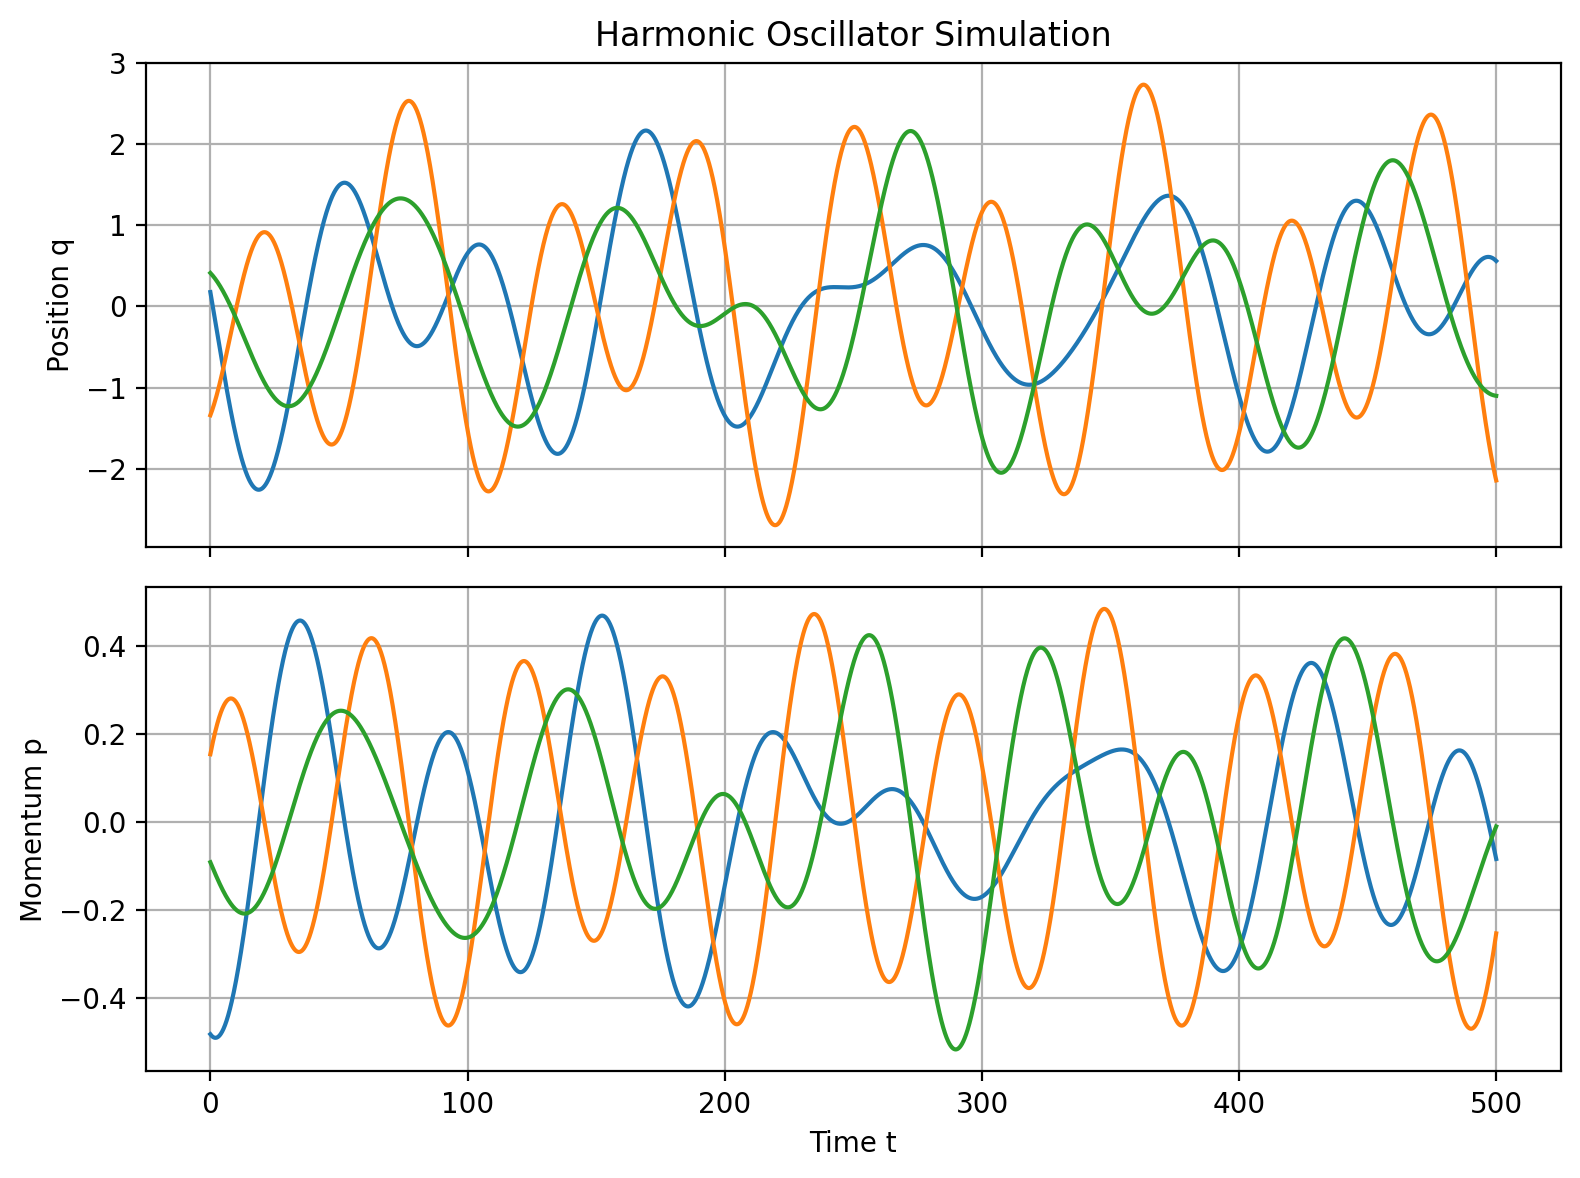

In [5]:
from matplotlib import pyplot as plt

# plot q and p
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax[0].plot(t, q)
ax[0].set_ylabel('Position q')
ax[0].set_title('Harmonic Oscillator Simulation')
ax[0].grid()
ax[1].plot(t, p)
ax[1].set_ylabel('Momentum p')
ax[1].set_xlabel('Time t')
ax[1].grid()
plt.tight_layout()
plt.show()

In [6]:
# t, q, p は前セルのシミュレーション出力。q, p の shape は (T, n)
T, n = q.shape
assert p.shape == (T, n)
dt = float(t[1] - t[0])

# 時系列で分割（情報漏洩を防ぐため、時間で切る）
frac_train = 0.6
frac_test  = 0.3
T_train = int(T * frac_train)
T_test  = int(T * frac_test)

q_train = jnp.asarray(q[:T_train])
p_train = jnp.asarray(p[:T_train])

q_test  = jnp.asarray(q[-T_test:])
p_test  = jnp.asarray(p[-T_test:])


In [7]:
print("Train shape:", q_train.shape, p_train.shape)
print("Test shape:", q_test.shape, p_test.shape)

Train shape: (3000, 3) (3000, 3)
Test shape: (1500, 3) (1500, 3)


In [ ]:

# 時刻ずらしペアを作成
def make_pairs(q_arr, p_arr, jump):    
    # 返り値 shape: (N, n) 同士の対応
    return (
        q_arr[:-jump], p_arr[:-jump],
        q_arr[jump:],  p_arr[jump:]
    )


jump = 1  # 例：10 ステップ先
train_curr_q, train_curr_p, train_tgt_q, train_tgt_p = make_pairs(q_train, p_train, jump)
test_curr_q,  test_curr_p,  test_tgt_q,  test_tgt_p  = make_pairs(q_test,  p_test,  jump)

N_train = train_curr_q.shape[0]
N_test  = test_curr_q.shape[0]
print("train pairs:", N_train, "test pairs:", N_test)

# バッチサンプラー
batch_size = 128
rng = jax.random.PRNGKey(0)

def sample_train_batch(rng):
    idx = jax.random.choice(rng, N_train, shape=(min(batch_size, N_train),), replace=False)
    return (
        train_curr_q[idx], train_curr_p[idx],
        train_tgt_q[idx],  train_tgt_p[idx],
    )


In [ ]:
rng, sub = jax.random.split(rng)
batch = sample_train_batch(sub)


AttributeError: 'tuple' object has no attribute 'shape'

In [8]:
batch[0].shape

(128, 3)

## G-Symp Net and Action Angle Network
Daigavane et al, 2022にあるブロック
\begin{equation}
f(x)=C x+W^T \operatorname{diag}(A) \sigma(W x+B)
\end{equation}

In [ ]:
class GSBlock(nn.Module):
    dim_config: int # dimenion of configuration space
    dim_hidden: int # hidden dimension of MLP
    activation: Callable = nn.relu 

    def setup(self):

        #self.W_affine = nn.Dense(self.dim_hidden, name="W_affine")
        self.W_affine = self.param("W_affine", nn.initializers.lecun_normal(),
                                    (self.dim_hidden, self.dim_config))
        self.B_bias = self.param("B_bias", nn.initializers.zeros, (self.dim_hidden,))
        self.A_diag = self.param("A_diag", nn.initializers.ones, (self.dim_hidden,))
        C_tmp = self.param("C_tmp", nn.initializers.zeros, (self.dim_config, self.dim_config))
        self.C_sym = (C_tmp + C_tmp.T) / 2.0  # 対称化
        #self.C_lin = nn.Dense(self.dim_config, use_bias=False, name="C_lin")

    @nn.compact
    def __call__(self, x):
        # x: (B, dim_config)
        y = self.activation(x @ self.W_affine.T + self.B_bias) # (B, dim_hidden)
        z = (y * self.A_diag) @ self.W_affine
        # (B, dim_hidden) ⊙ (dim_hidden,) -> (B, dim_hidden) -> (B, dim_config)

        # # (B, dim_config) -> (B, dim_hidden)
        # y = self.activation(self.W_affine(x))
        # # W_affine の kernel を取得（形状は (dim_hidden, dim_config) ※Flax Dense の慣習）
        # # z = (A ⊙ y) @ W   だが kernel は (d, m) なので転置して (m, d)
        # W_kernel = self.variables["params"]["W_affine"]["kernel"]  # (dim_hidden, dim_config)
        # z = (y * self.A_diag) @ W_kernel.T # (B, dim_config)

        return z + x @ self.C_sym # (B, dim_config)

class GSympNet(nn.Module):
    dim_config: int # dimenion of configuration space
    dim_hidden: int # hidden dimension of MLP
    num_blocks: int
    block_fcn: Callable = GSBlock # fucntion to generate block
    activation: Callable = nn.relu    

    def setup(self):
        assert self.num_blocks % 2 == 0, "num_blocks must be even number"
        self.blocks =[
            self.block_fcn(
                dim_config=self.dim_config,
                dim_hidden=self.dim_hidden,
                activation=self.activation,
                name=f'gsblock_{i}'
                ) for i in range(self.num_blocks)
        ]

    def __call__(self, q, p):
        for idx, blk in enumerate(self.blocks):
            if idx % 2 == 0:
                p = p + blk(q)
            else:
                q = q + blk(p)
        return q, p # I^x, I^y
    
    # 逆写像：層を逆順に、加算の符号を反転（可逆三角写像の基本）
    def inverse(self, q, p):
        for idx in reversed(range(self.num_blocks)):
            blk = self.blocks[idx]
            if idx % 2 == 0:           # p' = p + f(q)  =>  p = p' - f(q)
                p = p - blk(q)
            else:                    # q' = q + f(p)  =>  q = q' - f(p)
                q = q - blk(p)
        return q, p

class PolarCoordinates(nn.Module):
    dim_config: int # dimenion of configuration space

    def setup(self):
        pass

    def __call__(self, Ix, Iy):
        I = jnp.sqrt(Ix**2 + Iy**2)
        theta = jnp.arctan2(Iy, Ix)
        return I, theta

class GotosCanonicalPolarCoordinates(nn.Module):
    dim_config: int # dimenion of configuration space

    def setup(self):
        pass

    def __call__(self, Ix, Iy):
        I = 0.5 * (Ix**2 + Iy**2)
        theta = jnp.arctan2(-Iy, Ix)
        return I, theta

class InversePolarCoordinates(nn.Module):
    dim_config: int # dimenion of configuration space

    def setup(self):
        pass

    def __call__(self, I, theta):
        Ix = jnp.sqrt(I) * jnp.cos(theta)
        Iy = jnp.sqrt(I) * jnp.sin(theta)
        return Ix, Iy

class InverseGotosCanonicalPolarCoordinates(nn.Module):
    dim_config: int # dimenion of configuration space

    def setup(self):
        pass

    def __call__(self, I, theta):
        Ix = jnp.sqrt(2*I) * jnp.cos(theta)
        Iy = -jnp.sqrt(2*I) * jnp.sin(theta)
        return Ix, Iy

class MLP(nn.Module):
    dim_input: int
    dim_output: int
    dim_hidden: int
    activation: Callable = nn.relu
    res_connection: bool = False
    
    @nn.compact
    def __call__(self, x):
        y = nn.Dense(self.dim_hidden)(x)
        y = self.activation(y)
        y = nn.Dense(self.dim_output)(y)
        return y if self.res_connection == False else y + x

class MyActionAngleNetwork(nn.Module):
    dim_config: int # dimenion of configuration space
    dim_hidden: int # hidden dimension of MLP
    num_gsblocks: int
    type_polar: str = "canonical" # "canonical" or "normal"
    activation: Callable = nn.relu
    mlp_res_connection: bool = False

    def setup(self):
        self.gsymp_net = GSympNet(
            dim_config=self.dim_config,
            dim_hidden=self.dim_hidden,
            num_blocks=self.num_gsblocks,
            activation=self.activation
        )
        if self.type_polar == "normal":
            self.to_polar = PolarCoordinates(dim_config=self.dim_config)
            self.inv_polar = InversePolarCoordinates(dim_config=self.dim_config)
        elif self.type_polar == "canonical":
            self.to_polar = GotosCanonicalPolarCoordinates(dim_config=self.dim_config)
            self.inv_polar = InverseGotosCanonicalPolarCoordinates(dim_config=self.dim_config)
        self.theta_generator = MLP(
            dim_input=self.dim_config,
            dim_output=self.dim_config,
            dim_hidden=self.dim_hidden,
            activation=self.activation,
            res_connection=self.mlp_res_connection,
        )
        # self.to_polar = PolarCoordinates(dim_config=self.dim_config)
        # self.to_canonical_polar = GotosCanonicalPolarCoordinates(dim_config=self.dim_config)
        # self.inv_to_polar = InversePolarCoordinates(dim_config=self.dim_config)
        # self.inv_to_canonical_polar = InverseGotosCanonicalPolarCoordinates(dim_config=self.dim_config)

    def __call__(self, q, p, delta_t, train: bool = True):
        # (q, p) -> (Ix, Iy)
        Ix, Iy = self.gsymp_net(q, p)

        # (Ix, Iy) -> (I, theta)
        I, theta = self.to_polar(Ix, Iy)

        # I_ = I as I should be constant, only renew theta
        # theta is linear, so delta_t does not need to be small (the below is exact for any value of delta_t)
        theta_ = theta + delta_t * self.theta_generator(I)


        # wrap theta to [-pi, pi]
        theta_ = (theta_ + jnp.pi) % (2 * jnp.pi) - jnp.pi

        # inverse from future: (Ix_, Iy_) -> (q_, p_)
        Ix_, Iy_ = self.inv_polar(I, theta_)
        q_, p_ = self.gsymp_net.inverse(Ix_, Iy_)

        return q_, p_, I, theta


# Create model & Train

In [9]:

model = MyActionAngleNetwork(
    dim_config=n,
    dim_hidden=64,
    num_gsblocks=20,
    type_polar="canonical",
    activation=nn.sigmoid,
    mlp_res_connection=True
)


In [11]:
q0 = train_curr_q[:1]
p0 = train_curr_p[:1]
delta_t_scalar = jnp.asarray(dt * jump)  # スカラー


In [12]:
q0.shape

(1, 3)

In [ ]:


@jit
def train_step(
    params: Any,
    opt_state: Any, 
    x: jnp.ndarray,
    y: jnp.ndarray,
    delta_t: float,
    alpha: float,
    key: jax.random.PRNGKey
) -> Tuple[Any, Any, float]:
    # x: (B, 2n) current (q, p)
    # y: (B, 2n) target  (q, p)
    T = x.shape[0]
    n = x.shape[1] // 2
    q, p = x[:, :n], x[:, n:]  # (B, 3), (B, 3)

    def loss_fn(pp):
        q_, p_, I, _ = model.apply({'params': pp}, q, p, delta_t, train=True, rngs={'noise': key})
        #x_ = jnp.concatenate([q_, p_], axis=-1)
        
        # prediction loss
        loss_q_se = ((q_ - y[:, :n]) ** 2).mean()
        loss_p_se = ((p_ - y[:, n:]) ** 2).mean()

        # actions should be constant
        loss_action = jnp.var(I, axis=0).sum()

        return loss_q_se + loss_p_se + alpha * loss_action

    loss, grads = value_and_grad(loss_fn)(params)
    updates, opt_state = tx.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

@jit
def eval_batch(params, x, y, delta_t, key):
    n = x.shape[1] // 2
    q, p = x[:, :n], x[:, n:]  # (B, 3), (B, 3)
    
    q_, p_, _, _ = model.apply({'params': params}, q, p, delta_t, train=True, rngs={'noise': key})
    #x_ = jnp.concatenate([q_, p_], axis=-1)

    loss_q_mse = ((q_ - y[:, :n]) ** 2).mean()
    loss_p_mse = ((p_ - y[:, n:]) ** 2).mean()

    return loss_q_mse + loss_p_mse


In [11]:

wandb.login()  # すでに環境変数 WANDB_API_KEY があれば不要


wandb: Currently logged in as: shunsuke-kamiya (shunsuke-kamiya-the-university-of-tokyo) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [12]:
key = random.PRNGKey(0)
eval_key  = random.PRNGKey(42)


In [13]:

run = wandb.init(
    project="aan_scratch_harm_osc",
    name="aan_scratch_test_harm_osc",
    config={
            "model": "MyActionAngleNetwork",
            "num_gsblocks": 4,
            "dim_hidden": 64,
            "type_polar": "canonical",
            "activation": "relu",
            "T": 400,
            "dt": 0.1,
            "n": 3,
            "opt": dict(optimizer="adamw", lr=3e-4, weight_decay=1e-4, grad_clip=1.0),
            "rng": dict(train_seed=int(key[0]), eval_seed=int(eval_key[0])),
        },
)
                    
                 

In [15]:
rng = jax.random.PRNGKey(0)
params = model.init(rng, jnp.array([0.0,0.0,0.0]), jnp.array([0.0,0.0,0.0]), float(0.1))["params"]
#params = model.init(rng, q0, p0, delta_t_scalar)["params"]

# オプティマイザ
tx = optax.adam(1e-3)
opt_state = tx.init(params)

In [ ]:
num_steps = 10000
log_every = 100

alpha = 0.1  # weight for action constancy loss

#delta_t_scalar = jnp.asarray(dt * jump)

for step in range(1, num_steps + 1):
    rng, sub = jax.random.split(rng)
    batch = sample_train_batch(sub)
    # batch = train_curr_q[idx], train_curr_p[idx], train_tgt_q[idx],  train_tgt_p[idx],

    params, opt_state, train_loss = train_step(
        params=params,
        opt_state=opt_state,
        x=jnp.concatenate([batch[0], batch[1]], axis=-1),
        y=jnp.concatenate([batch[2], batch[3]], axis=-1),
        alpha=alpha,
        delta_t=delta_t_scalar,
        key=rng
    )

    if step % log_every == 0 or step == 1:
        test_loss = eval_batch(
            params=params,
            x=jnp.concatenate([test_curr_q, test_curr_p], axis=-1), 
            y=jnp.concatenate([test_tgt_q, test_tgt_p], axis=-1),
            delta_t=delta_t_scalar,
            key=eval_key
        )
        # test_loss = eval_batch(
        #     params, test_curr_q, test_curr_p, test_tgt_q, test_tgt_p, delta_t_scalar
        # )
        print(f"step {step:5d}  train_loss {float(train_loss):.6f}  test_loss {float(test_loss):.6f}")
        wandb.log({
            "train/loss": float(train_loss),
            "test/loss": float(test_loss),
            "step": step,
        })

step     1  train_loss 0.009030  test_loss 0.000029
step   100  train_loss 0.008232  test_loss 0.000029
step   200  train_loss 0.008990  test_loss 0.000028
step   300  train_loss 0.007397  test_loss 0.000029
step   400  train_loss 0.008402  test_loss 0.000029
step   500  train_loss 0.008727  test_loss 0.000030
step   600  train_loss 0.007091  test_loss 0.000030
step   700  train_loss 0.007363  test_loss 0.000032
step   800  train_loss 0.006979  test_loss 0.000032
step   900  train_loss 0.007447  test_loss 0.000031
step  1000  train_loss 0.007214  test_loss 0.000032
step  1100  train_loss 0.006780  test_loss 0.000032
step  1200  train_loss 0.006425  test_loss 0.000033
step  1300  train_loss 0.006896  test_loss 0.000033
step  1400  train_loss 0.006891  test_loss 0.000033
step  1500  train_loss 0.006470  test_loss 0.000033
step  1600  train_loss 0.006648  test_loss 0.000034
step  1700  train_loss 0.005920  test_loss 0.000033
step  1800  train_loss 0.006023  test_loss 0.000034
step  1900  

# 最初、全然ダメだったのでCodexに質問
Scratchでaction angle networkを自分で組んでみてる。それが action_angle_networks/notebooks/e2025_0905_aan_scratch.ipynbなんだけど、全然学習しない。既存の著者実装とどこがどう違うのか知りたい。まず、モデルの作り方はあっているか確認してほしい。上記のnotebookを見て、著者実装のモデルの実装部分と照らし合わせて確認してみて。

## 回答
把握したよ。あなたの scratch 実装は大枠で著者実装の AAN と同じ構成になっていますが、いくつか重要な相違があり、そこが学習不安定・発散の原因になりやすいです。モデル部分に絞って、対応関係と差分を整理します。

対応関係（合っている点）

+ エンコード→行動角座標→角速度で角だけ時間発展→デコードという流れは一致
    + Scratch: GSympNet で (q,p) -> (Ix, Iy)、極座標化で (I, θ)、theta_generator(I) で角速度、GSympNet.inverse で復元
    + 参照: notebooks/e2025_0905_aan_scratch.ipynb:666-694
    + 著者実装: FlowEncoder で (q,p) を潜在へ、polar_action_angles=True のとき cartesian_to_polar で (actions, angles)、angular_velocity_net(actions)、FlowDecoder で復元
    + 参照: action_angle_networks/models.py:669 以降
+ 角速度ネットの入出力は一致
    + Scratch: theta_generator(I) は dim_input = dim_output = n の MLP
    + 参照: notebooks/e2025_0905_aan_scratch.ipynb:644-654
    + 著者実装: angular_velocity_net は [latent_size,...,output_dims] の MLP
    + 参照: action_angle_networks/train.py:194-211
+ エンコーダ／デコーダが互いに可逆
    + Scratch: GSympNet と inverse を自前実装
    + 参照: notebooks/e2025_0905_aan_scratch.ipynb:418-487
    + 著者実装: 同一フローの forward/inverse を FlowEncoder/FlowDecoder で共有
    + 参照: action_angle_networks/models.py:627-666

### 重要な違い（学習に効きやすい点）
+ エンコーダの“せん断”の作り
    + 著者は Shear 正規化フローで「勾配ベースのコンディショナ」を使い、せん断追加項を必ずポテンシャルの勾配にしています（シンプレクティック性を満たしやすい）。
    + 参照: action_angle_networks/models.py:293-322（create_shear_flow → GradientBasedConditioner）
    + Scratch の GSBlock は z= W^T (a ⊙ act(Wx+b)) なので z はスカラー和の勾配になっていて良いのですが、さらに + C_lin(x)（一般の線形）が足されています。
    + C_lin のカーネルが対称でない限り、これはポテンシャルの勾配とは一致せず、層としてのシンプレクティック性が崩れます。可逆性は保てますが、長期安定性や学習のしやすさに悪影響になりえます。
    + 参照: notebooks/e2025_0905_aan_scratch.ipynb:368-420
+ 極座標の定義
    + 著者実装は「通常の極座標」(r, θ) を “actions, angles” と呼んでいます（r = sqrt(x^2+y^2)）。
    + 参照: action_angle_networks/models.py:79-93 と 669 以降
    + Scratch はデフォルトで「正準な極座標」（I = 0.5(Ix^2+Iy^2), θ = atan2(-Iy, Ix)）を採用。
    + 参照: notebooks/e2025_0905_aan_scratch.ipynb:632-642, 524-530, 568-574
    + どちらでも理論上は学べますが、I のスケールが大きくなるため、角速度ネットの入力分布が著者実装と大きく異なります。未スケールのまま大きな I を入れると発散しやすいです。
+ 角度のラップ処理
    + 著者は予測後の角度を [-π, π] に折り返しています。
    + 参照: action_angle_networks/models.py:701-706
    + Scratch はラップ無し（大きな角に成長すると sin/cos の数値安定性が落ちることがあります）。
+ 活性化や層の深さ
    + 著者の flow 構成は層数が多く（デフォルト20）、活性も sigmoid（config依存）で抑制的。AAN の MLP もスキップ接続あり。
    + 参照: action_angle_networks/configs/harmonic_motion/action_angle_flow.py
    + Scratch はブロック数 4、活性 relu、スキップ無し。表現力や勾配の安定性に差が出ます。
+ 正規化（スケーリング）
    + 著者は StandardScaler で q/p をゼロ平均・単位分散にしています。
    + 参照: action_angle_networks/train.py:160-176
    + Scratch は未スケール。その上で損失が「総和（sum）」になっており、バッチサイズ依存で勾配が巨大になりやすいです（著者は平均）。
    + 参照: Scratch train_step の loss_q_se + loss_p_se は sum、著者は optax.l2_loss を mean 集計

### まず直すと良い最小ポイント（モデル側）
- [x] GSBlock の線形項を勾配由来に制限
    + return z + self.C_lin(x) の C_lin を外すか、カーネルを対称に制約（初期化時に 0.5*(W+W^T) に投影する）して“勾配の線形項”にする。
- [x]角度のラップを追加
    + theta_ = (theta_ + jnp.pi) % (2*jnp.pi) - jnp.pi（著者と同じ）
- [ ] 角速度 MLP の入力スケールを揃える
    + 正準 I をそのまま使うなら、I を標準化してから theta_generator に入力（学習前に q/p の標準化 or I の標準化）。
- [x] フロー層の表現力を少し増やす
    + num_gsblocks を増やす、dim_hidden を少し上げる、activation を sigmoid に揃えてみる（著者設定に近づける）。
- [x] MLP にスキップ接続を入れる
    + 著者の MLP はデフォルトで residual を持ちます（models.MLP(..., skip_connections=True)）。theta_generator も 1層なら不要だが、深くするなら residual を。
### 学習が発散している補足（損失・前処理側の違い）
- [ ] 損失の総和→平均に変更（バッチ依存をなくす）
    + 著者は optax.l2_loss を mean でまとめています。Scratch でも .mean() に。
- [ ] 入力の標準化を導入
    + Train 分布から q/p の mean/std を計算し標準化してから学習（推論時は逆変換）。
- [ ] 角速度・アクションの分散正則化の重み
    + 著者デフォルトは actions: 1.0。Scratch の alpha=0.1 は弱め。強めてみる価値あり（データやスケール依存）。
- [ ] 角度更新の安定化
    + delta_t が大きい場合は線形学習を崩しやすいので、小さめ jump から始めて徐々に増やす（著者は線形スケジュールあり）。

以上より、「モデルの作り方」自体は大筋で合っています。特にエンコード/デコードの可逆構造と「I のみから角速度を出して角だけ進める」発想は著者実装と一致しています。違いで効きやすいのは、(1) GSBlock に任意線形を足している点（シンプレクティック性を崩しやすい）、(2) 角度ラップ無し、(3) 入力・I の未スケール、(4) 損失の総和、の4点です。

この4点をまず直してみますか？必要なら、ノートブックにパッチ（角度ラップ、損失のmean化、簡易StandardScaler、C_lin削除または対称化）を入れる提案コードを用意します

In [29]:
# Roll out model predictions from initial state across full horizon
import jax
import jax.numpy as jnp

# Convert true series to JAX arrays
q_true = jnp.asarray(q)
p_true = jnp.asarray(p)
T_total = int(q_true.shape[0])
n_dim = int(q_true.shape[1])

# Initial state and per-step delta_t
q0_roll = q_true[:1].squeeze(axis=0) if q_true.ndim==2 else q_true[:1]
p0_roll = p_true[:1].squeeze(axis=0) if p_true.ndim==2 else p_true[:1]
delta_t_infer = jnp.asarray(float(dt))

def _step_fn(carry, _):
    q_curr, p_curr = carry
    q_next, p_next, _, _ = model.apply({'params': params}, q_curr, p_curr, delta_t_infer, train=False)
    return (q_next, p_next), (q_next, p_next)

# Rollout T_total-1 steps to get length T_total with the initial appended
(_, _), (qs_seq, ps_seq) = jax.lax.scan(_step_fn, (q0_roll, p0_roll), None, length=max(T_total-1, 0))
q_pred = jnp.concatenate([q0_roll[None,...], qs_seq], axis=0) if T_total>0 else q0_roll
p_pred = jnp.concatenate([p0_roll[None,...], ps_seq], axis=0) if T_total>0 else p0_roll

# Remove batch axis
q_pred = jnp.squeeze(q_pred, axis=1) if q_pred.ndim==3 else q_pred
p_pred = jnp.squeeze(p_pred, axis=1) if p_pred.ndim==3 else p_pred

print('q_pred shape:', q_pred.shape, 'p_pred shape:', p_pred.shape)


q_pred shape: (5000, 3) p_pred shape: (5000, 3)


In [30]:
jnp.concatenate([q0_roll, qs_seq], axis=0)

TypeError: Cannot concatenate arrays with different numbers of dimensions: got (3,), (4999, 3).

In [31]:
qs_seq.shape

(4999, 3)

In [32]:
q0_roll.shape

(3,)

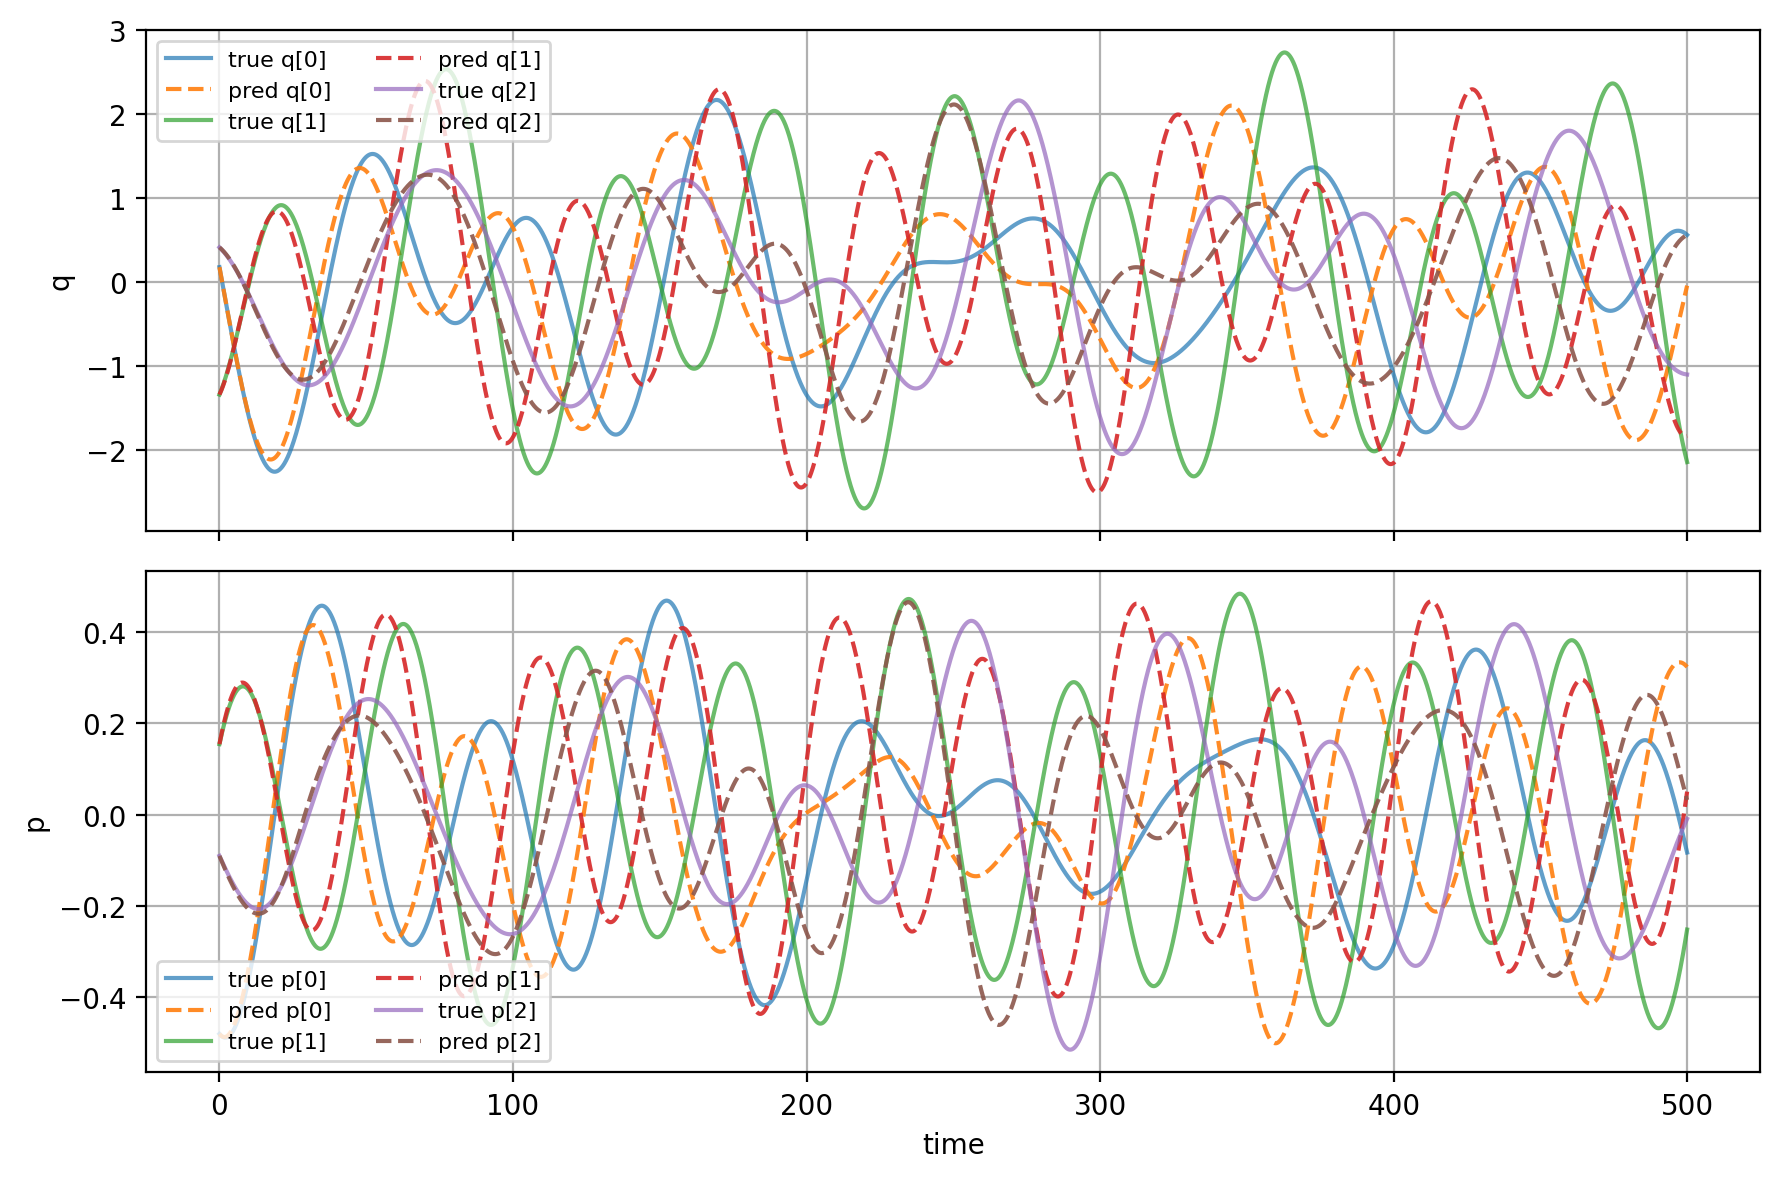

In [33]:
# Plot true vs predicted trajectories
import matplotlib.pyplot as plt
t_arr = np.asarray(t)
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Positions
for i in range(q_pred.shape[1]):
    axes[0].plot(t_arr, np.asarray(q)[:, i], label=f'true q[{i}]', alpha=0.7)
    axes[0].plot(t_arr, np.asarray(q_pred)[:, i], '--', label=f'pred q[{i}]', alpha=0.9)
axes[0].set_ylabel('q')
axes[0].grid(True)
axes[0].legend(ncol=2, fontsize=8)

# Momenta
for i in range(p_pred.shape[1]):
    axes[1].plot(t_arr, np.asarray(p)[:, i], label=f'true p[{i}]', alpha=0.7)
    axes[1].plot(t_arr, np.asarray(p_pred)[:, i], '--', label=f'pred p[{i}]', alpha=0.9)
axes[1].set_ylabel('p')
axes[1].set_xlabel('time')
axes[1].grid(True)
axes[1].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()
